# Traffic Project 2 — Advanced Visualization, Uncertainty & Explainability

**This notebook covers techniques from the lecture Pt3 (xAI) notebook:**

| Section | Technique | From Lecture |
|---------|-----------|-------------|
| 1 | Folium Maps (stations, traffic heatmaps, graph edges, spatial errors) | Spec |
| 2 | Peak Detection & Zoom Analysis | Pt3 Cell 64 |
| 3 | Local Attention Heatmap (single sample) | Pt3 Cell 66 |
| 4 | Global Attention Strategy (full test set) | Pt3 Cell 68 |
| 5 | SHAP Feature Importance (bar chart) | Pt3 Cell 70 |
| 6 | SHAP Waterfall (feature contributions in traffic-count units) | Pt3 Cell 71 |
| 7 | SHAP Pulse Heatmap (temporal feature shifts around peak) | Pt3 Cell 72 |
| 8 | Stress Test: Temperature Perturbation (+/- 10 deg F) | Pt3 Cell 75 |
| 9 | MC Dropout — Epistemic Uncertainty (confidence intervals) | Pt3 Cells 62 & 78 |
| 10 | Epistemic Uncertainty + Temperature Overlay | Pt3 Cell 78 |

**Prerequisite:** Run Notebooks 01 and 02 first so the processed data and trained models exist.

In [30]:
!pip install folium shap -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, HeatMapWithTime
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import gc
import shap

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [32]:
# ── Configuration ──
PROJECT_DIR = Path("C:/Users/owner/Downloads/Masters/Masters_Spring_2026/Advanced Deep Learning/Traffic Project 2")
PROCESSED   = PROJECT_DIR / "processed"
MODEL_DIR   = PROJECT_DIR / "models"

SEQ_LENGTH    = 24
BATCH_SIZE    = 64
TARGET_YEAR   = 2024

---
## Load Data & Rebuild Models

In [33]:
# ── Load processed data ──
df = pd.read_csv(PROCESSED / f'ct_traffic_weather_{TARGET_YEAR}.csv', parse_dates=['timestamp'])
stations = pd.read_csv(PROCESSED / 'ct_stations.csv')
station_map = pd.read_csv(PROCESSED / 'station_node_mapping.csv')
adj_matrix = np.load(PROCESSED / 'adj_matrix_knn.npy')

# Weather station info (re-derive from mapping)
weather_mapping = pd.read_csv(PROCESSED / 'traffic_to_weather_mapping.csv')

print(f"Data: {len(df):,} rows, {df['station_id'].nunique()} stations")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Data: 270,120 rows, 56 stations
Date range: 2024-01-02 00:00:00 -> 2024-12-31 23:00:00


In [34]:
# ── Reproduce the exact same train/test split from Notebook 02 ──
target_col = 'traffic_count'
exclude_cols = ['station_id', 'timestamp', 'traffic_count']
feature_cols = [c for c in df.columns if c not in exclude_cols
                and df[c].dtype in ['float64', 'int64', 'float32', 'int32']]

station_counts = df.groupby('station_id').size().sort_values(ascending=False)
primary_station = station_counts.index[0]
df_single = df[df['station_id'] == primary_station].sort_values('timestamp').reset_index(drop=True)
df_single = df_single.dropna(subset=feature_cols + [target_col])

split_idx = int(len(df_single) * 0.8)
train_df = df_single.iloc[:split_idx].copy()
test_df  = df_single.iloc[split_idx:].copy()

# Scale
scaler_x = StandardScaler()
scaler_y = StandardScaler()
train_x_scaled = scaler_x.fit_transform(train_df[feature_cols])
train_y_scaled = scaler_y.fit_transform(train_df[[target_col]])
test_x_scaled = scaler_x.transform(test_df[feature_cols])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

# Sequences
def create_sequences(features, target, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

X_train_np, y_train_np = create_sequences(train_x_scaled, train_y_scaled, SEQ_LENGTH)
X_test_np,  y_test_np  = create_sequences(test_x_scaled,  test_y_scaled,  SEQ_LENGTH)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),   batch_size=BATCH_SIZE, shuffle=False)

# Inverse-transform test targets
y_test_true_inv = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()

# Aligned metadata for the test window (skip first SEQ_LENGTH rows)
test_window_df = test_df.iloc[SEQ_LENGTH:].copy().reset_index(drop=True)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

X_train: torch.Size([6758, 24, 27]), X_test: torch.Size([1672, 24, 27])
Features (27): ['temp_c', 'dewpoint_c', 'wind_mph', 'precip_in', 'visibility_mi', 'is_raining', 'is_snowing', 'is_foggy', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'wind_gust', 'traffic_t-1', 'traffic_t-2', 'traffic_t-3', 'traffic_t-6', 'traffic_t-12', 'traffic_t-24', 'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_6h']


In [35]:
# ── Rebuild & Load the Transformer model (from Notebook 02) ──
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TrafficTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, output_dim=1):
        super(TrafficTransformer, self).__init__()
        self.encoder_input_layer = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers, num_layers=num_layers
        )
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.encoder_input_layer(x)
        x = self.pos_encoder(x)
        out = self.transformer_encoder(x)
        out = self.decoder(out[:, -1, :])
        return out


class TrafficLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1):
        super(TrafficLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out


# Load saved weights
model = TrafficTransformer(input_dim=X_train.shape[2], d_model=64, nhead=4, num_layers=2).to(device)
model.load_state_dict(torch.load(str(MODEL_DIR / 'best_traffic_transformer.pth'),
                                  map_location=device, weights_only=True))
model.eval()
print('Transformer model loaded.')

lstm_model = TrafficLSTM(input_dim=X_train.shape[2], hidden_dim=64, num_layers=2).to(device)
lstm_model.load_state_dict(torch.load(str(MODEL_DIR / 'best_traffic_lstm.pth'),
                                       map_location=device, weights_only=True))
lstm_model.eval()
print('LSTM model loaded.')

Transformer model loaded.
LSTM model loaded.


In [36]:
# ── Generate predictions for both models ──
def get_predictions(model, X, device):
    model.eval()
    loader = DataLoader(TensorDataset(X, torch.zeros(len(X), 1)),
                        batch_size=BATCH_SIZE, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch_X, _ in loader:
            preds.append(model(batch_X.to(device)).cpu().numpy())
    return np.vstack(preds)

tf_preds_scaled = get_predictions(model, X_test, device)
tf_preds = scaler_y.inverse_transform(tf_preds_scaled).flatten()

lstm_preds_scaled = get_predictions(lstm_model, X_test, device)
lstm_preds = scaler_y.inverse_transform(lstm_preds_scaled).flatten()

# Persistence baseline
y_test_naive = torch.cat([y_test[0:1], y_test[:-1]])
y_test_naive_inv = scaler_y.inverse_transform(y_test_naive.numpy().reshape(-1, 1)).flatten()

print(f"Predictions generated: {len(tf_preds)} test samples")

Predictions generated: 1672 test samples


---
## Section 1 — Folium Maps

In [37]:
# == 1a: Station Location Map (Traffic + Weather) ==
# FIX: CartoDB Voyager tiles (OpenStreetMap blocks requests without referer)
from branca.element import Template, MacroElement

ct_center = [41.6, -72.7]
m1 = folium.Map(
    location=ct_center, zoom_start=9,
    tiles='https://{s}.basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}{r}.png',
    attr='&copy; <a href="https://carto.com/">CARTO</a> &copy; <a href="https://www.openstreetmap.org/copyright">OSM</a>'
)

# Traffic stations (blue circles, sized by avg volume)
for _, row in station_map.iterrows():
    avg_traffic = df[df['station_id'] == row['station_id']]['traffic_count'].mean()
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(4, min(15, avg_traffic / 500)),
        color='blue', fill=True, fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>Traffic Station: {row['station_id']}</b><br>"
            f"Avg Traffic: {avg_traffic:.0f} veh/hr<br>"
            f"Lat: {row['latitude']:.4f}, Lon: {row['longitude']:.4f}",
            max_width=250
        ),
        tooltip=f"Station {row['station_id']}"
    ).add_to(m1)

# Weather stations (red markers)
try:
    import requests as req
    resp = req.get("https://mesonet.agron.iastate.edu/geojson/network/CT_ASOS.geojson", timeout=15)
    gj = resp.json()
    for feat in gj['features']:
        props = feat['properties']
        sid = props.get('sid', props.get('id', ''))
        coords = feat['geometry']['coordinates']
        sname = props.get('sname', '')
        folium.Marker(
            location=[coords[1], coords[0]],
            icon=folium.Icon(color='red', icon='cloud'),
            popup=f"<b>ASOS: {sid}</b><br>{sname}",
            tooltip=f"Weather: {sid}"
        ).add_to(m1)
except:
    print("Could not fetch ASOS station coords.")

# == Legend ==
legend_html = '''
{% macro html(this, kwargs) %}
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     border:2px solid #555; font-size:13px; font-family:Arial;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
  <b style="font-size:15px;">CT Station Map (2024)</b><br><br>
  <svg width="14" height="14"><circle cx="7" cy="7" r="6" fill="blue" opacity="0.6"/></svg>
  &nbsp;Traffic Station (FHWA TMAS)<br>
  <span style="font-size:11px; color:gray; margin-left:20px;">Circle size = avg hourly volume</span><br><br>
  <svg width="14" height="14"><polygon points="7,1 13,13 1,13" fill="red"/></svg>
  &nbsp;Weather Station (ASOS)<br>
  <hr style="margin:6px 0;">
  <span style="font-size:11px; color:#555;">Data: FHWA TMAS + Iowa State Mesonet</span>
</div>
{% endmacro %}
'''
legend = MacroElement()
legend._template = Template(legend_html)
m1.get_root().add_child(legend)

m1.save(str(PROCESSED / 'map_station_locations.html'))
print("Saved: map_station_locations.html")

from IPython.display import HTML
HTML(m1._repr_html_())


Saved: map_station_locations.html


In [38]:
# == 1b: Traffic Volume Heatmap ==
# Shows AVERAGE HOURLY traffic volume per station across all of 2024
from branca.element import Template, MacroElement

m2 = folium.Map(location=ct_center, zoom_start=9, tiles='CartoDB dark_matter')

# Compute average traffic per station
heat_data = []
station_stats = []
for _, row in station_map.iterrows():
    avg_vol = df[df['station_id'] == row['station_id']]['traffic_count'].mean()
    if not np.isnan(avg_vol):
        heat_data.append([row['latitude'], row['longitude'], avg_vol])
        station_stats.append(avg_vol)

HeatMap(
    heat_data,
    min_opacity=0.4,
    max_zoom=13,
    radius=25,
    blur=15,
    gradient={0.4: 'blue', 0.65: 'lime', 0.8: 'yellow', 1: 'red'}
).add_to(m2)

# == Title + Legend ==
min_stat = f'{min(station_stats):.0f}'
max_stat = f'{max(station_stats):.0f}'

title_legend = '''
{% macro html(this, kwargs) %}
<div style="position:fixed; top:15px; left:50%%; transform:translateX(-50%%); z-index:1000;
     background:rgba(0,0,0,0.85); padding:10px 24px; border-radius:8px;
     font-family:Arial; text-align:center; box-shadow:2px 2px 6px rgba(0,0,0,0.5);">
  <span style="color:white; font-size:18px; font-weight:bold;">
    Average Hourly Traffic Volume &mdash; Connecticut 2024
  </span><br>
  <span style="color:#ccc; font-size:12px;">
    Each point = one FHWA TMAS station &bull; Color intensity = avg vehicles/hour
  </span>
</div>
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:rgba(0,0,0,0.85); padding:12px 16px; border-radius:8px;
     font-size:13px; font-family:Arial; color:white; box-shadow:2px 2px 6px rgba(0,0,0,0.5);">
  <b>Volume Legend</b><br><br>
  <div style="display:flex; align-items:center; gap:4px;">
    <div style="width:140px; height:14px; border-radius:3px;
         background:linear-gradient(to right, blue, lime, yellow, red);"></div>
  </div>
  <div style="display:flex; justify-content:space-between; width:140px; font-size:11px; margin-top:2px;">
    <span>Low</span><span>Med</span><span>High</span>
  </div><br>
  <span style="font-size:11px; color:#aaa;">
''' + f'    Range: {min_stat} &ndash; {max_stat} vehicles/hour\n' + '''  </span>
</div>
{% endmacro %}
'''

legend2 = MacroElement()
legend2._template = Template(title_legend)
m2.get_root().add_child(legend2)

m2.save(str(PROCESSED / 'map_traffic_heatmap.html'))
print("Saved: map_traffic_heatmap.html")
print(f'Volume range: {min(station_stats):.0f} - {max(station_stats):.0f} veh/hr')

from IPython.display import HTML
HTML(m2._repr_html_())


Saved: map_traffic_heatmap.html


In [39]:
# == 1c: Graph Edges Map (KNN adjacency) ==
m3 = folium.Map(
    location=ct_center, zoom_start=9,
    tiles='https://{s}.basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}{r}.png',
    attr='&copy; CARTO &copy; OSM'
)

coords_list = station_map[['latitude', 'longitude']].values
n_nodes = len(coords_list)

# Draw edges
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj_matrix[i, j] > 0:
            weight = adj_matrix[i, j]
            folium.PolyLine(
                locations=[
                    [coords_list[i, 0], coords_list[i, 1]],
                    [coords_list[j, 0], coords_list[j, 1]]
                ],
                color='red',
                weight=max(1, weight * 4),
                opacity=0.5,
                tooltip=f'Edge weight: {weight:.3f}'
            ).add_to(m3)

# Draw nodes
for _, row in station_map.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6, color='navy', fill=True, fill_opacity=0.8,
        popup=f"Node {row['node_idx']}: {row['station_id']}"
    ).add_to(m3)

m3.save(str(PROCESSED / 'map_graph_edges.html'))
print("Saved: map_graph_edges.html")

from IPython.display import HTML
HTML(m3._repr_html_())


Saved: map_graph_edges.html


In [40]:
# == 1d: Hourly Traffic Animation (HeatMapWithTime) ==
# FIX: Normalize weights to [0,1] so frames actually differ visually
from branca.element import Template, MacroElement

m4 = folium.Map(location=ct_center, zoom_start=9, tiles='CartoDB positron')

# Compute hourly averages per station
hourly_frames = []
all_vals = []  # for global normalization

for hour in range(24):
    frame_data = []
    for _, row in station_map.iterrows():
        mask = (df['station_id'] == row['station_id']) & (df['timestamp'].dt.hour == hour)
        avg_vol = df.loc[mask, 'traffic_count'].mean()
        if not np.isnan(avg_vol) and avg_vol > 0:
            frame_data.append([row['latitude'], row['longitude'], avg_vol])
            all_vals.append(avg_vol)
    hourly_frames.append(frame_data)

# Normalize all weights to [0, 1] using global min/max
global_min = min(all_vals) if all_vals else 0
global_max = max(all_vals) if all_vals else 1
global_range = global_max - global_min if global_max > global_min else 1

hourly_frames_norm = []
for frame in hourly_frames:
    norm_frame = []
    for lat, lon, val in frame:
        norm_val = (val - global_min) / global_range
        norm_frame.append([lat, lon, norm_val])
    hourly_frames_norm.append(norm_frame)

HeatMapWithTime(
    hourly_frames_norm,
    index=[f'{h:02d}:00' for h in range(24)],
    auto_play=True,
    speed_step=0.5,
    max_opacity=0.8,
    radius=30,
    min_opacity=0.1,
    use_local_extrema=False,  # use global scale so frames are comparable
    gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(m4)

# == Title ==
title_html4 = '''
{% macro html(this, kwargs) %}
<div style="position:fixed; top:15px; left:50%%; transform:translateX(-50%%);
     z-index:1000; background:white; padding:10px 24px; border-radius:8px;
     border:2px solid #333; font-family:Arial; text-align:center;
     box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b style="font-size:16px;">Hourly Traffic Volume Animation &mdash; CT 2024</b><br>
  <span style="font-size:12px; color:#555;">
    Use the slider or play button below to see traffic shift across 24 hours
  </span>
</div>
{% endmacro %}
'''
title4 = MacroElement()
title4._template = Template(title_html4)
m4.get_root().add_child(title4)

m4.save(str(PROCESSED / 'map_hourly_traffic_animation.html'))
print("Saved: map_hourly_traffic_animation.html")
print(f'Global traffic range: {global_min:.0f} - {global_max:.0f} veh/hr')
print(f'Frames: {len(hourly_frames_norm)}, Points per frame: {[len(f) for f in hourly_frames_norm]}')

from IPython.display import HTML
HTML(m4._repr_html_())


Saved: map_hourly_traffic_animation.html


---
## Section 2 — Peak Detection & Zoom Analysis

*(Adapted from Pt3 Cell 64)*  
Find the highest traffic hour in the test set and zoom in to see how each model performed.

In [41]:
# ── Find extremes in test set ──
peak_idx = np.argmax(y_test_true_inv)
peak_val = y_test_true_inv[peak_idx]
peak_time = test_window_df.iloc[peak_idx]['timestamp']

# Also find the lowest traffic period
trough_idx = np.argmin(y_test_true_inv)
trough_val = y_test_true_inv[trough_idx]
trough_time = test_window_df.iloc[trough_idx]['timestamp']

# Extreme weather indices
if 'temp_c' in test_window_df.columns:
    h_idx = test_window_df['temp_c'].idxmax()  # hottest hour
    c_idx = test_window_df['temp_c'].idxmin()  # coldest hour
else:
    h_idx = peak_idx
    c_idx = trough_idx

print(f"Peak Traffic: {peak_val:.0f} vehicles at {peak_time}")
print(f"Trough:       {trough_val:.0f} vehicles at {trough_time}")
print(f"Hottest Hour: idx {h_idx}  |  Coldest Hour: idx {c_idx}")

Peak Traffic: 1146 vehicles at 2024-10-23 08:00:00
Trough:       18 vehicles at 2024-12-25 04:00:00
Hottest Hour: idx 15  |  Coldest Hour: idx 1490


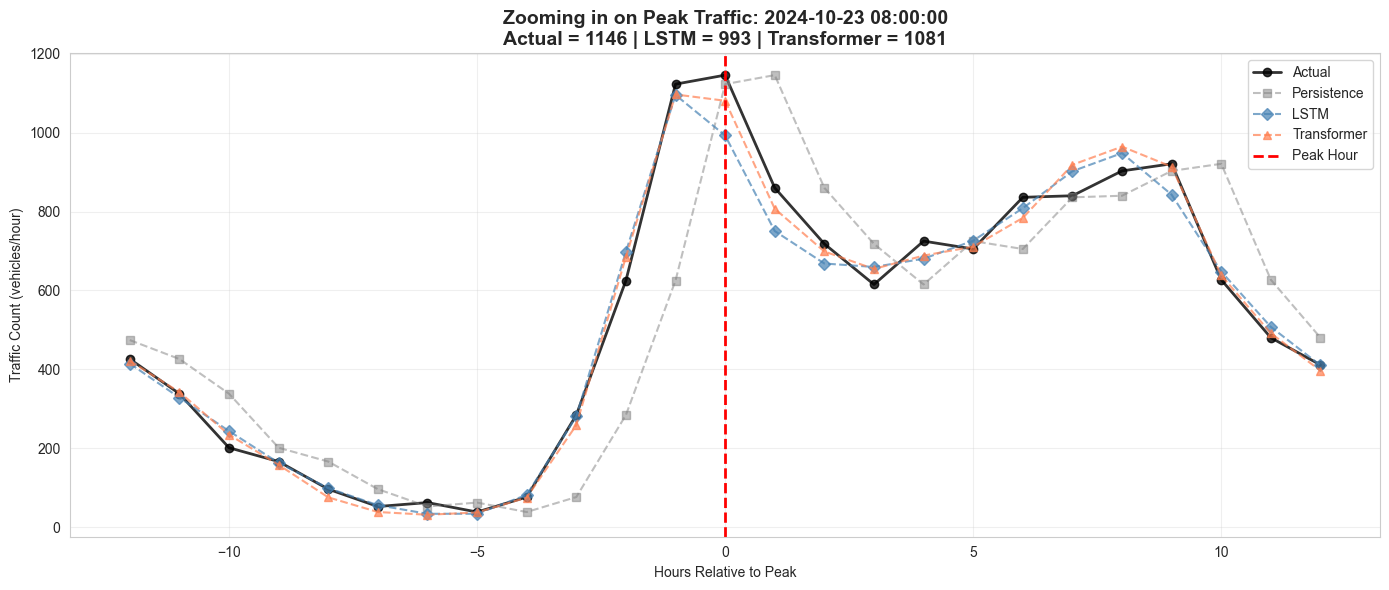

In [42]:
# ── Zoom: 12 hours before and after the peak ──
window = 12
start_z = max(0, peak_idx - window)
end_z   = min(len(y_test_true_inv), peak_idx + window + 1)
relative_hours = np.arange(start_z - peak_idx, end_z - peak_idx)

plt.figure(figsize=(14, 6))
plt.plot(relative_hours, y_test_true_inv[start_z:end_z], 'ko-', label='Actual', alpha=0.8, lw=2)
plt.plot(relative_hours, y_test_naive_inv[start_z:end_z], 's--', color='gray', label='Persistence', alpha=0.5)
plt.plot(relative_hours, lstm_preds[start_z:end_z], 'D--', color='steelblue', label='LSTM', alpha=0.7)
plt.plot(relative_hours, tf_preds[start_z:end_z], '^--', color='coral', label='Transformer', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Peak Hour')

plt.title(f"Zooming in on Peak Traffic: {peak_time}\n"
          f"Actual = {peak_val:.0f} | LSTM = {lstm_preds[peak_idx]:.0f} | "
          f"Transformer = {tf_preds[peak_idx]:.0f}",
          fontsize=14, fontweight='bold')
plt.xlabel('Hours Relative to Peak')
plt.ylabel('Traffic Count (vehicles/hour)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_peak_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Local Attention Heatmap

*(Adapted from Pt3 Cell 66)*  
Extract the attention matrix for the peak-traffic sample and visualize which historical lags the model focuses on.

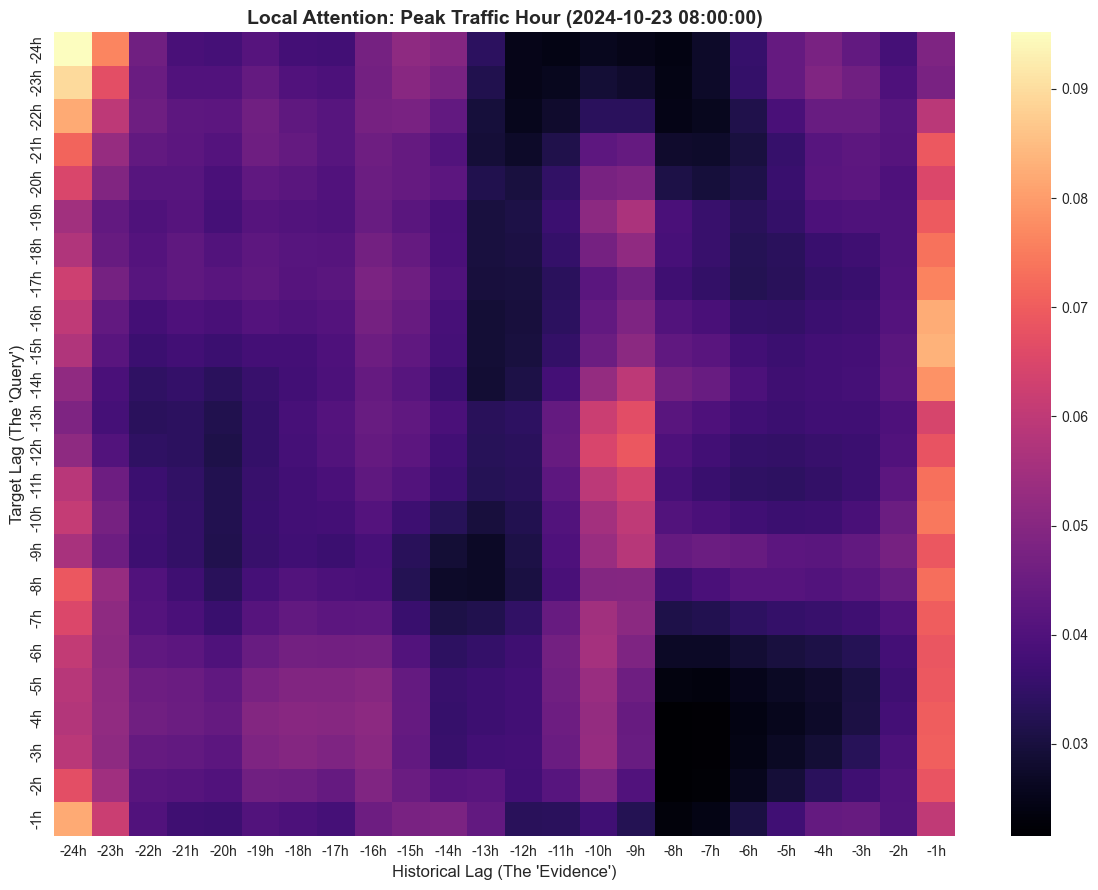


--- Investigating High-Attention Lag (Index 0, -24h) ---
Time: 2024-10-22 08:00:00
Temperature: 10.0 C
Traffic Count: 956


In [43]:
# ── Local attention for the peak sample ──
model.eval()
peak_sample = X_test[peak_idx:peak_idx+1].to(device)

with torch.no_grad():
    x = model.encoder_input_layer(peak_sample)
    x = model.pos_encoder(x)
    _, attn_weights_local = model.transformer_encoder.layers[0].self_attn(
        x, x, x, need_weights=True, average_attn_weights=True
    )

attn_matrix = attn_weights_local.squeeze().cpu().numpy()  # [24, 24]
lag_labels = [f"-{24-i}h" for i in range(24)]

plt.figure(figsize=(12, 9))
sns.heatmap(attn_matrix, cmap='magma',
            xticklabels=lag_labels, yticklabels=lag_labels)
plt.title(f"Local Attention: Peak Traffic Hour ({peak_time})",
          fontsize=14, fontweight='bold')
plt.xlabel("Historical Lag (The 'Evidence')", fontsize=12)
plt.ylabel("Target Lag (The 'Query')", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_local_attention.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Deep dive into the hottest attention spot ──
hot_index = np.unravel_index(attn_matrix.argmax(), attn_matrix.shape)[1]
peak_features_df = test_df.iloc[peak_idx:peak_idx + SEQ_LENGTH]
hot_hour_data = peak_features_df.iloc[hot_index]

print(f"\n--- Investigating High-Attention Lag (Index {hot_index}, {lag_labels[hot_index]}) ---")
print(f"Time: {hot_hour_data['timestamp']}")
if 'temp_c' in hot_hour_data.index:
    print(f"Temperature: {hot_hour_data['temp_c']:.1f} C")
print(f"Traffic Count: {hot_hour_data['traffic_count']:.0f}")

---
## Section 4 — Global Attention Strategy

*(Adapted from Pt3 Cell 68)*  
Average attention weights across the entire test set to see the model's general strategy.

Analyzing global attention patterns across the test set...


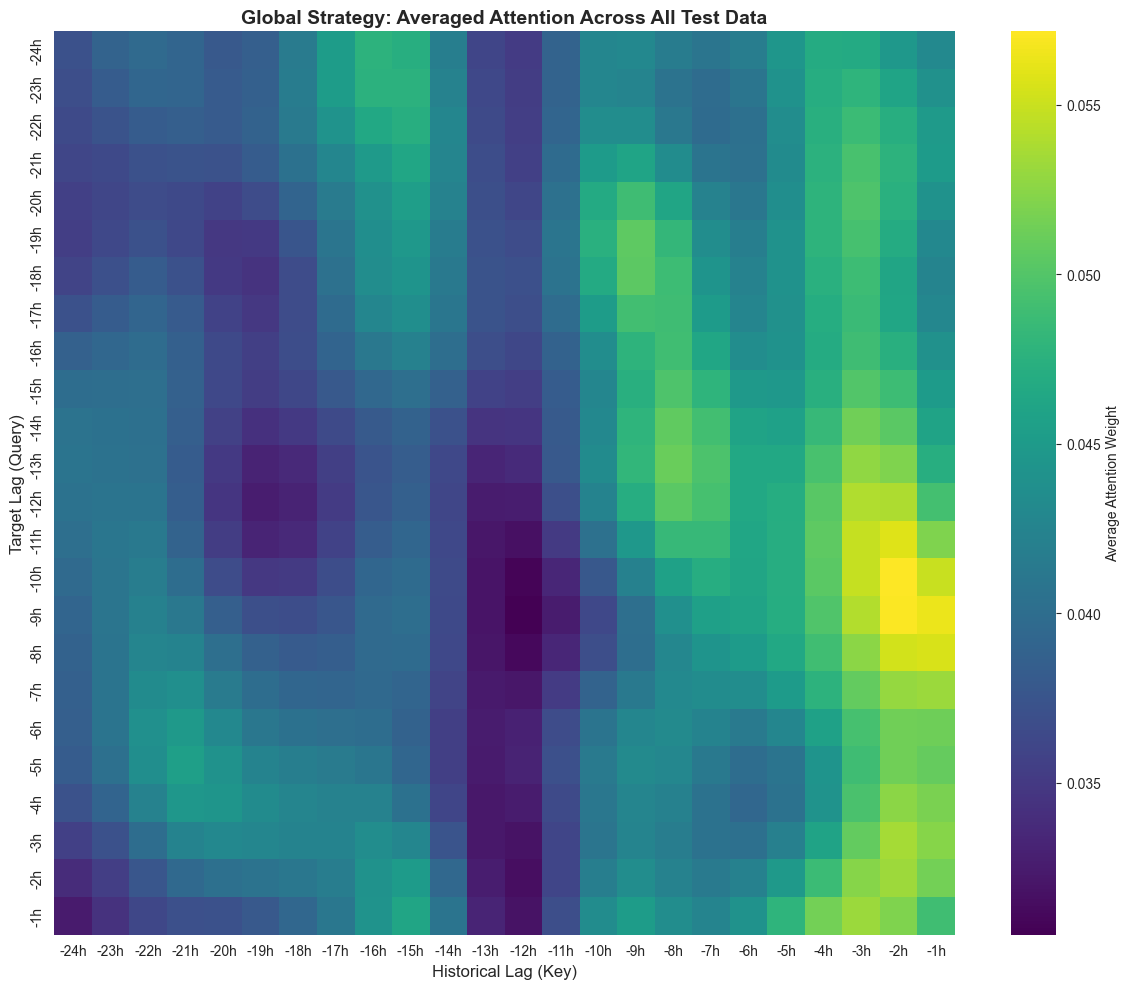


--- The Model's Favorite Clues ---
1. Lag -3h (Weight: 1.217)
2. Lag -2h (Weight: 1.217)
3. Lag -1h (Weight: 1.159)


In [44]:
# ── Global attention across all test samples ──
model.eval()
all_attn_weights = []

print("Analyzing global attention patterns across the test set...")
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        x = model.encoder_input_layer(batch_X)
        x = model.pos_encoder(x)
        _, weights = model.transformer_encoder.layers[0].self_attn(
            x, x, x, need_weights=True, average_attn_weights=True
        )
        all_attn_weights.append(weights.cpu().numpy())

global_avg_attn = np.vstack(all_attn_weights).mean(axis=0)

plt.figure(figsize=(12, 10))
sns.heatmap(global_avg_attn, cmap='viridis',
            xticklabels=lag_labels, yticklabels=lag_labels,
            cbar_kws={'label': 'Average Attention Weight'})
plt.title("Global Strategy: Averaged Attention Across All Test Data",
          fontsize=14, fontweight='bold')
plt.xlabel("Historical Lag (Key)", fontsize=12)
plt.ylabel("Target Lag (Query)", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_global_attention.png', dpi=150, bbox_inches='tight')
plt.show()

# Top-3 most influential lags
importance_by_lag = global_avg_attn.sum(axis=0)
top_lags = np.argsort(importance_by_lag)[-3:][::-1]

print("\n--- The Model's Favorite Clues ---")
for i, lag_idx in enumerate(top_lags):
    print(f"{i+1}. Lag {lag_labels[lag_idx]} (Weight: {importance_by_lag[lag_idx]:.3f})")

---
## Section 5 — SHAP Feature Importance

*(Adapted from Pt3 Cell 70)*  
Which features drive the Transformer's traffic predictions?

In [45]:
# ── SHAP Setup using GradientExplainer (faster than KernelExplainer for PyTorch) ──
model.eval()
y_std = float(scaler_y.scale_[0])
actual_feature_names = feature_cols[:X_train.shape[2]]

print("Initializing SHAP GradientExplainer...")
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)].to(device)
explainer = shap.GradientExplainer(model, background)

# SHAP values for the peak sample
peak_sample = X_test[peak_idx:peak_idx+1].to(device)
sv_peak = explainer.shap_values(peak_sample)
if isinstance(sv_peak, list): sv_peak = sv_peak[0]
sv_peak = np.squeeze(sv_peak)  # [24, n_features]

print(f"SHAP values shape: {sv_peak.shape}")

Initializing SHAP GradientExplainer...
SHAP values shape: (24, 27)


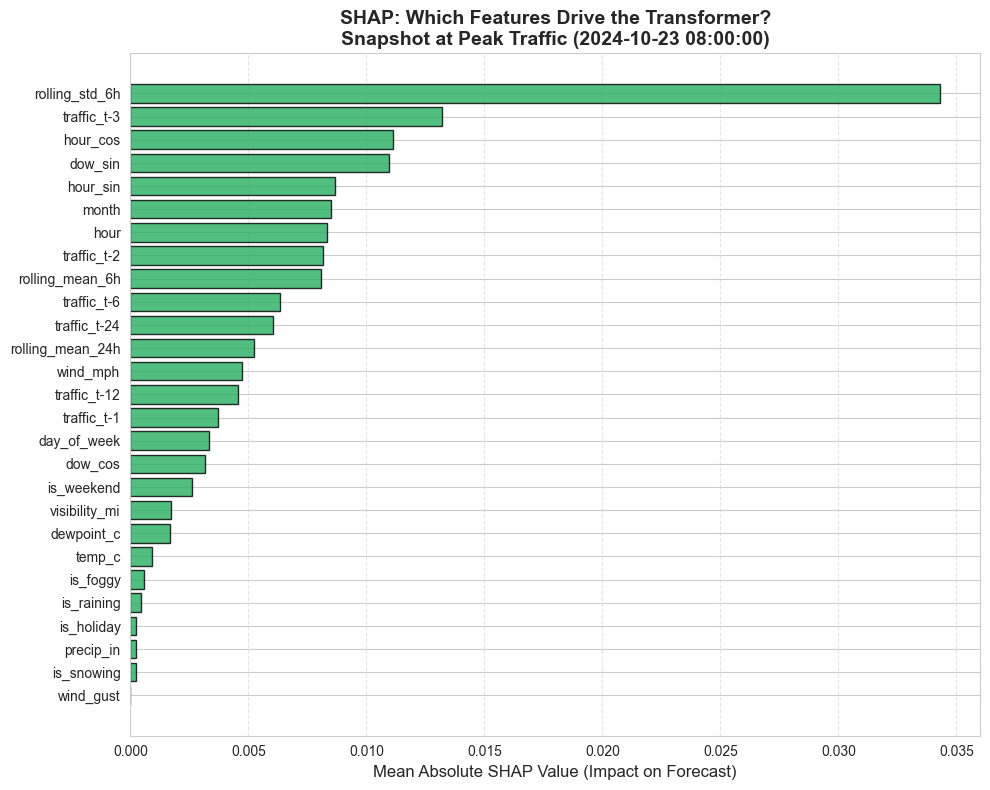

In [46]:
# ── Feature importance bar chart ──
if sv_peak.ndim == 3:
    importance = np.abs(sv_peak).mean(axis=(0, 1))
else:
    importance = np.abs(sv_peak).mean(axis=0)

importance_flat = importance.flatten()
actual_feature_names = feature_cols[:len(importance_flat)]

shap_df = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': importance_flat
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(shap_df['Feature'], shap_df['Importance'],
         color='#27ae60', edgecolor='black', alpha=0.8)
plt.title(f"SHAP: Which Features Drive the Transformer?\n"
          f"Snapshot at Peak Traffic ({peak_time})",
          fontsize=14, fontweight='bold')
plt.xlabel("Mean Absolute SHAP Value (Impact on Forecast)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — SHAP Waterfall (Feature Contributions)

*(Adapted from Pt3 Cell 71)*  
How much does each feature push the prediction UP or DOWN from the baseline, in actual traffic-count units?

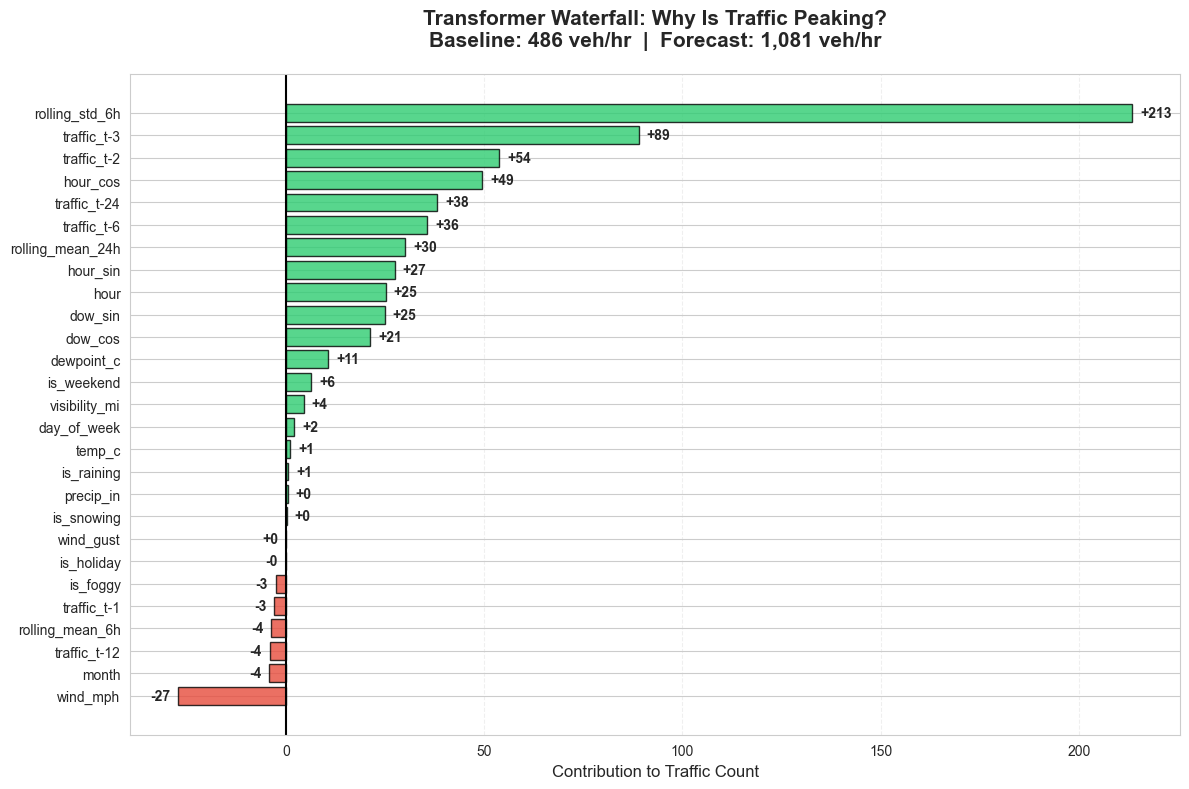

In [47]:
# ── Waterfall: feature contributions in traffic-count units ──
model.eval()
with torch.no_grad():
    background_preds = model(background).cpu().numpy()
    base_value_scaled = background_preds.mean()
    peak_pred_scaled = model(peak_sample).cpu().numpy().flatten()[0]

base_value_traffic = float(scaler_y.inverse_transform([[base_value_scaled]])[0][0])
peak_pred_traffic  = float(scaler_y.inverse_transform([[peak_pred_scaled]])[0][0])

# Sum SHAP across the 24h window to get total feature impact
if sv_peak.ndim == 3:
    total_shap = sv_peak.sum(axis=(0, 1)).flatten() * y_std
else:
    total_shap = sv_peak.sum(axis=0).flatten() * y_std

actual_feature_names = feature_cols[:len(total_shap)]

waterfall_df = pd.DataFrame({
    'Feature': actual_feature_names,
    'Contribution': total_shap
}).sort_values(by='Contribution')

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in waterfall_df['Contribution']]
bars = plt.barh(waterfall_df['Feature'], waterfall_df['Contribution'],
                color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    width = bar.get_width()
    label_x = width + (2 if width > 0 else -2)
    plt.text(label_x, bar.get_y() + bar.get_height()/2,
             f'{width:+,.0f}', va='center',
             ha='left' if width > 0 else 'right', fontweight='bold', fontsize=10)

plt.axvline(x=0, color='black', lw=1.5)
plt.title(f"Transformer Waterfall: Why Is Traffic Peaking?\n"
          f"Baseline: {base_value_traffic:,.0f} veh/hr  |  "
          f"Forecast: {peak_pred_traffic:,.0f} veh/hr",
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Contribution to Traffic Count", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 — SHAP Pulse Heatmap

*(Adapted from Pt3 Cell 72)*  
How does the Transformer's reasoning shift across the hours surrounding the peak?

Calculating SHAP for 25 hours around the peak...


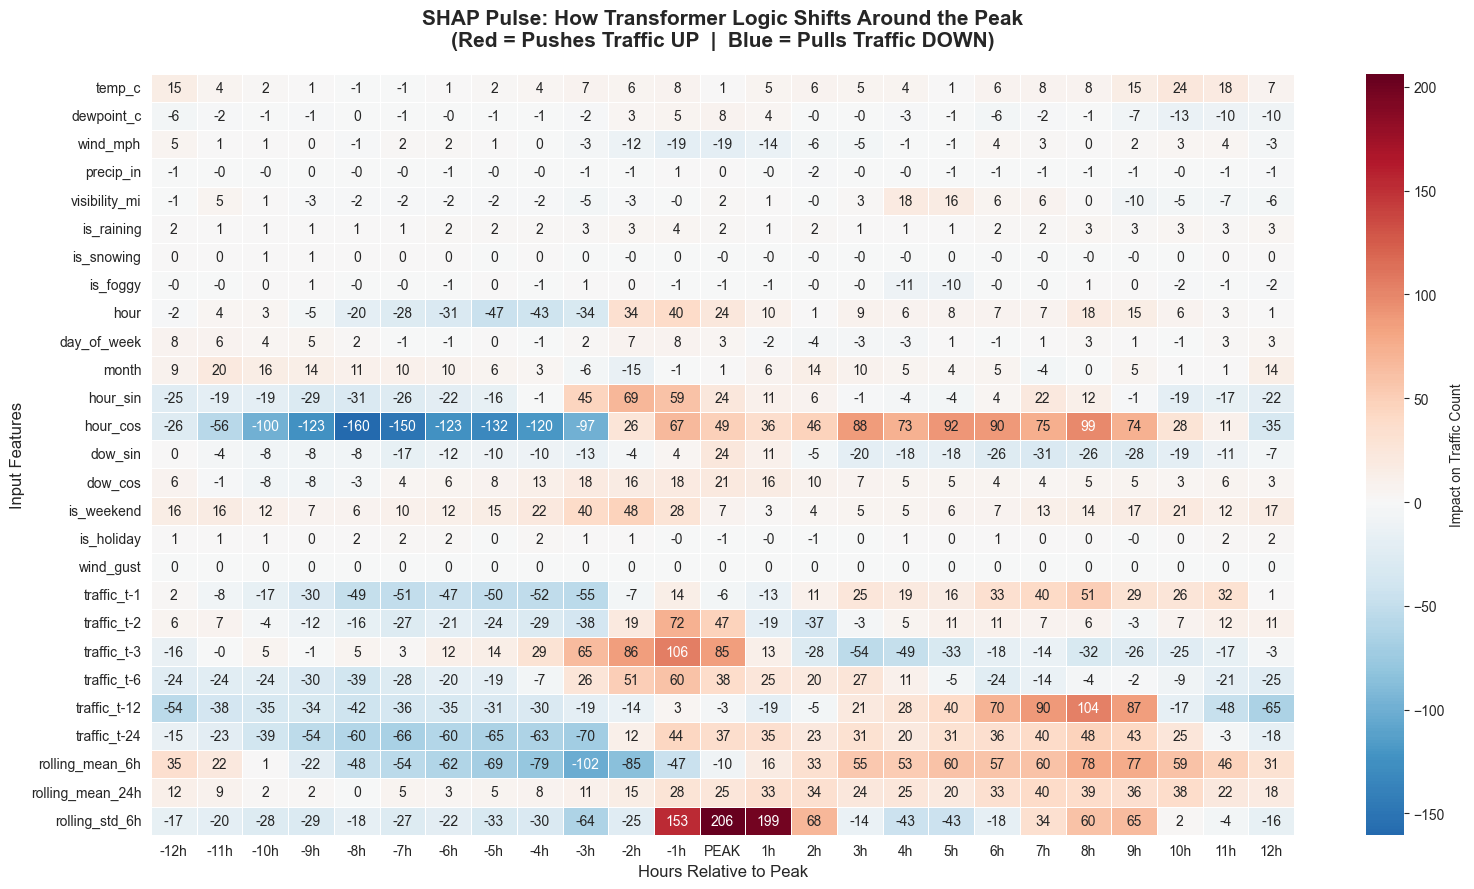

In [48]:
# ── SHAP Pulse: heatmap of feature importance across time around the peak ──
pulse_start = max(0, peak_idx - 12)
pulse_end   = min(len(X_test), peak_idx + 13)
X_window = X_test[pulse_start:pulse_end].to(device)

print(f"Calculating SHAP for {len(X_window)} hours around the peak...")
sv_raw = explainer.shap_values(X_window)
if isinstance(sv_raw, list):
    sv_window = sv_raw[0]
else:
    sv_window = sv_raw

sv_window = np.squeeze(sv_window)

# Sum across the 24h lookback → total feature impact per forecast hour
feature_impact_scaled = sv_window.sum(axis=1)  # [n_samples, n_features]
feature_impact = feature_impact_scaled * y_std

relative_hours = np.arange(-(peak_idx - pulse_start), (pulse_end - peak_idx))
time_labels = [f"{h}h" if h != 0 else "PEAK" for h in relative_hours]

actual_feature_names = feature_cols[:feature_impact.shape[1]]

heatmap_df = pd.DataFrame(
    feature_impact.T,
    index=actual_feature_names,
    columns=time_labels
)

plt.figure(figsize=(16, 9))
sns.heatmap(heatmap_df, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            cbar_kws={'label': 'Impact on Traffic Count'}, linewidths=0.5)
plt.title(f"SHAP Pulse: How Transformer Logic Shifts Around the Peak\n"
          f"(Red = Pushes Traffic UP  |  Blue = Pulls Traffic DOWN)",
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Hours Relative to Peak", fontsize=12)
plt.ylabel("Input Features", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_shap_pulse.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — Stress Test: Temperature Perturbation

*(Adapted from Pt3 Cell 75)*  
What happens to traffic predictions if we simulate a heatwave (+10 F) or cold snap (-10 F)?  
This is a 'poor man\'s confidence interval' — good for operational awareness.

In [49]:
# ── Stress Test Setup ──
model.eval()

# Find the index of 'temp_c' in the feature columns
temp_feat_idx = feature_cols.index('temp_c') if 'temp_c' in feature_cols else 0
temp_std = float(scaler_x.scale_[temp_feat_idx])

def get_prediction_traffic(input_tensor):
    """Get standard (non-dropout) prediction in traffic-count units."""
    with torch.no_grad():
        scaled_preds = model(input_tensor.to(device)).cpu().numpy()
        return scaler_y.inverse_transform(scaled_preds.reshape(-1, 1)).flatten()

# Create perturbed versions of test set
# +10F = +5.56C change in temperature
X_hotter = X_test.clone()
X_hotter[:, :, temp_feat_idx] += (5.56 / temp_std)

X_colder = X_test.clone()
X_colder[:, :, temp_feat_idx] -= (5.56 / temp_std)

y_pred_orig    = get_prediction_traffic(X_test)
y_pred_hotter  = get_prediction_traffic(X_hotter)
y_pred_colder  = get_prediction_traffic(X_colder)

print(f"Predictions generated for baseline, +10F, and -10F scenarios.")

Predictions generated for baseline, +10F, and -10F scenarios.


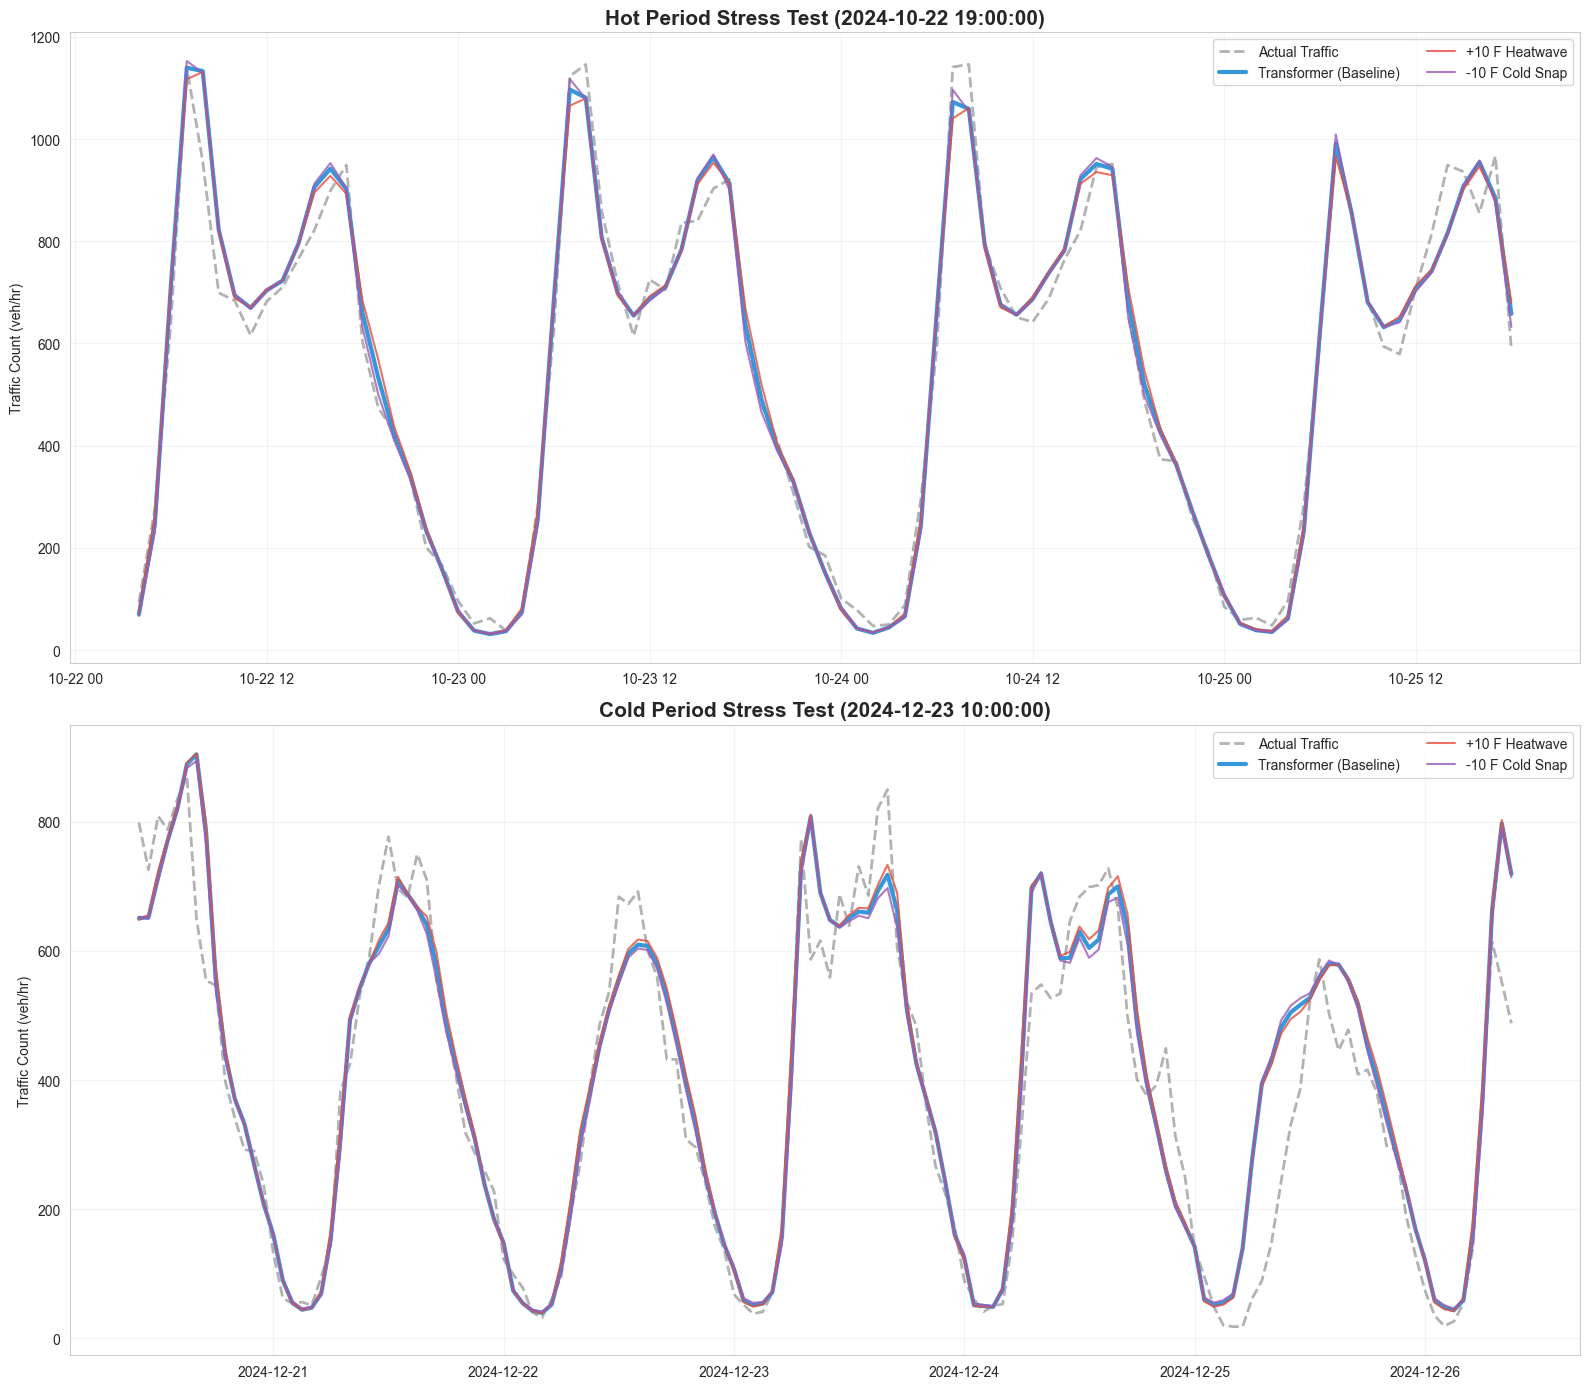

In [50]:
# ── Stress Test Visualization ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
span = 72  # 3 days before and after

def plot_stress_test(ax, center_idx, title, show_hotter=True, show_colder=True):
    start = max(0, center_idx - span)
    end   = min(len(y_pred_orig), center_idx + span)

    actual   = y_test_true_inv[start:end]
    baseline = y_pred_orig[start:end]
    hotter   = y_pred_hotter[start:end]
    colder   = y_pred_colder[start:end]
    times    = test_window_df['timestamp'].iloc[start:end]

    ax.plot(times, actual,   label='Actual Traffic', color='black', alpha=0.3, lw=2, ls='--')
    ax.plot(times, baseline, label='Transformer (Baseline)', color='#3498db', lw=3)
    if show_hotter:
        ax.plot(times, hotter, label='+10 F Heatwave', color='#e74c3c', ls='-', alpha=0.8)
    if show_colder:
        ax.plot(times, colder, label='-10 F Cold Snap', color='#9b59b6', ls='-', alpha=0.8)

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_ylabel('Traffic Count (veh/hr)')
    ax.legend(loc='upper right', ncol=2)
    ax.grid(True, alpha=0.2)

# Hot period
hot_time = test_window_df.iloc[h_idx]['timestamp'] if h_idx < len(test_window_df) else 'N/A'
plot_stress_test(ax1, h_idx, f"Hot Period Stress Test ({hot_time})")

# Cold period
cold_time = test_window_df.iloc[c_idx]['timestamp'] if c_idx < len(test_window_df) else 'N/A'
plot_stress_test(ax2, c_idx, f"Cold Period Stress Test ({cold_time})")

plt.tight_layout()
plt.savefig(PROCESSED / 'viz_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — MC Dropout: Epistemic Uncertainty

*(Adapted from Pt3 Cells 62 & 78)*  

**Monte Carlo Dropout** keeps dropout active during inference by calling `model.train()`.  
Running N forward passes produces a distribution → the spread = **epistemic uncertainty**  
(what the model *doesn't know* because it hasn't seen enough similar data).

In [51]:
# ── MC Dropout helper (from Pt3 Cell 62) ──
def get_mc_stats(inputs, n_iter=30):
    """
    Monte Carlo Dropout: run N forward passes with dropout ON
    to estimate epistemic uncertainty.
    
    Returns: (mean, lower_95, upper_95) in original traffic-count units.
    """
    model.train()  # Enable dropout for MC sampling
    preds = []
    with torch.no_grad():
        for _ in range(n_iter):
            p = model(inputs.to(device)).cpu().numpy()
            preds.append(scaler_y.inverse_transform(p.reshape(-1, 1)))
    model.eval()  # Restore eval mode
    preds = np.array(preds)  # [n_iter, samples, 1]
    mean = preds.mean(axis=0).flatten()
    std  = preds.std(axis=0).flatten()
    return mean, mean - 1.96 * std, mean + 1.96 * std

Running MC Dropout (30 forward passes)...


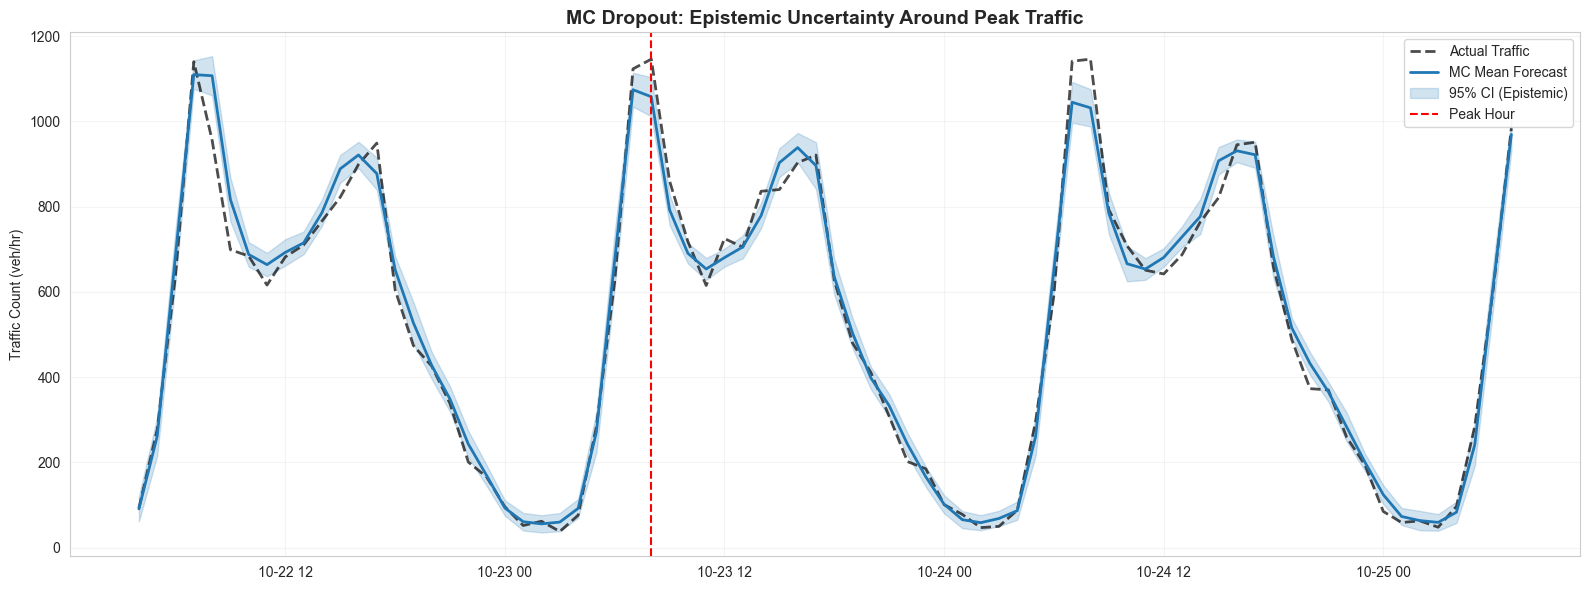

In [52]:
# ── MC Dropout uncertainty around the traffic peak ──
span_mc = 48
mc_start = max(0, peak_idx - span_mc)
mc_end   = min(len(X_test), peak_idx + span_mc)

print("Running MC Dropout (30 forward passes)...")
mu, lo, hi = get_mc_stats(X_test[mc_start:mc_end])
times_mc = test_window_df['timestamp'].iloc[mc_start:mc_end].values
actual_mc = y_test_true_inv[mc_start:mc_end]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(times_mc, actual_mc, 'k--', lw=2, label='Actual Traffic', alpha=0.7)
ax.plot(times_mc, mu, color='C0', lw=2, label='MC Mean Forecast')
ax.fill_between(times_mc, lo, hi, color='C0', alpha=0.2, label='95% CI (Epistemic)')

ax.axvline(x=times_mc[peak_idx - mc_start], color='red', ls='--', lw=1.5, label='Peak Hour')
ax.set_title('MC Dropout: Epistemic Uncertainty Around Peak Traffic',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Traffic Count (veh/hr)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(PROCESSED / 'viz_mc_dropout_peak.png', dpi=150, bbox_inches='tight')
plt.show()

  MC Dropout for Hot Period: +10 F St...
  MC Dropout for Cold Period: -10 F S...


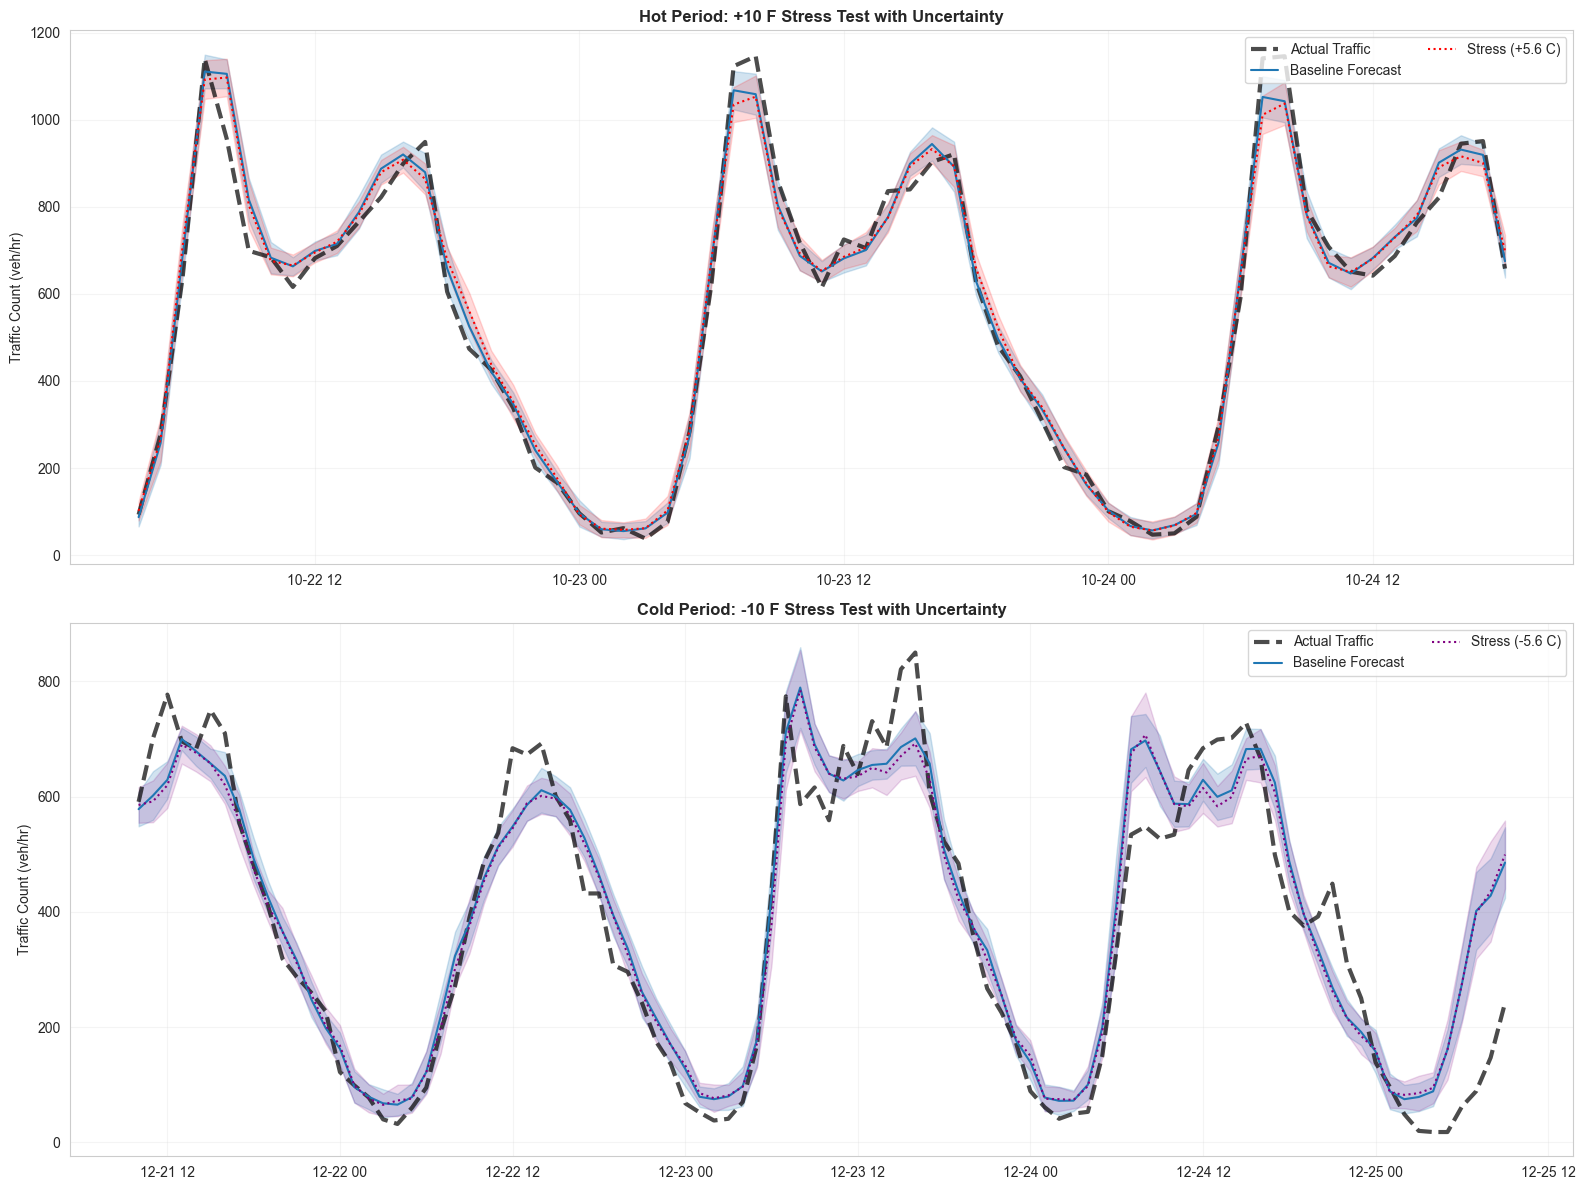

In [53]:
# ── MC Dropout: Stress Test + Uncertainty combined ──
# (From Pt3 Cells 62 plots 3&4)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
span_stress = 48

for ax, center, title, offset_c, col in zip(
    [ax1, ax2], [h_idx, c_idx],
    ['Hot Period: +10 F Stress Test with Uncertainty',
     'Cold Period: -10 F Stress Test with Uncertainty'],
    [5.56, -5.56], ['red', 'purple']
):
    s = max(0, center - span_stress)
    e = min(len(X_test), center + span_stress)

    # Create modified input
    X_mod = X_test[s:e].clone()
    X_mod[:, :, temp_feat_idx] += (offset_c / temp_std)

    # MC Dropout for both baseline and modified
    print(f"  MC Dropout for {title[:20]}...")
    m_base, lo_base, hi_base = get_mc_stats(X_test[s:e])
    m_mod, lo_mod, hi_mod    = get_mc_stats(X_mod)
    t = test_window_df['timestamp'].iloc[s:e].values

    ax.plot(t, y_test_true_inv[s:e], color='black', ls='--', lw=3,
            label='Actual Traffic', alpha=0.7)
    ax.plot(t, m_base, color='C0', label='Baseline Forecast')
    ax.fill_between(t, lo_base, hi_base, color='C0', alpha=0.2)
    ax.plot(t, m_mod, color=col, ls=':', label=f'Stress ({offset_c:+.1f} C)')
    ax.fill_between(t, lo_mod, hi_mod, color=col, alpha=0.15)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Traffic Count (veh/hr)')
    ax.legend(loc='upper right', ncol=2)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(PROCESSED / 'viz_mc_stress_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — Epistemic Uncertainty + Temperature Overlay

*(Adapted from Pt3 Cell 78)*  
Dual-axis plots: traffic predictions with confidence intervals on the left axis, temperature signal on the right.

In [54]:
# ── Epistemic uncertainty with temperature overlay ──
span_epi = 72
h_start, h_end = max(0, h_idx - span_epi), min(len(X_test), h_idx + span_epi)
c_start, c_end = max(0, c_idx - span_epi), min(len(X_test), c_idx + span_epi)

# Compute MC stats for both periods
print("Computing epistemic uncertainty for hot period...")
mu_h_base, lo_h_base, hi_h_base = get_mc_stats(X_test[h_start:h_end])
X_h_hot = X_test[h_start:h_end].clone()
X_h_hot[:, :, temp_feat_idx] += (5.56 / temp_std)
mu_h_hot, lo_h_hot, hi_h_hot = get_mc_stats(X_h_hot)

print("Computing epistemic uncertainty for cold period...")
mu_c_base, lo_c_base, hi_c_base = get_mc_stats(X_test[c_start:c_end])
X_c_cold = X_test[c_start:c_end].clone()
X_c_cold[:, :, temp_feat_idx] -= (5.56 / temp_std)
mu_c_cold, lo_c_cold, hi_c_cold = get_mc_stats(X_c_cold)

Computing epistemic uncertainty for hot period...
Computing epistemic uncertainty for cold period...


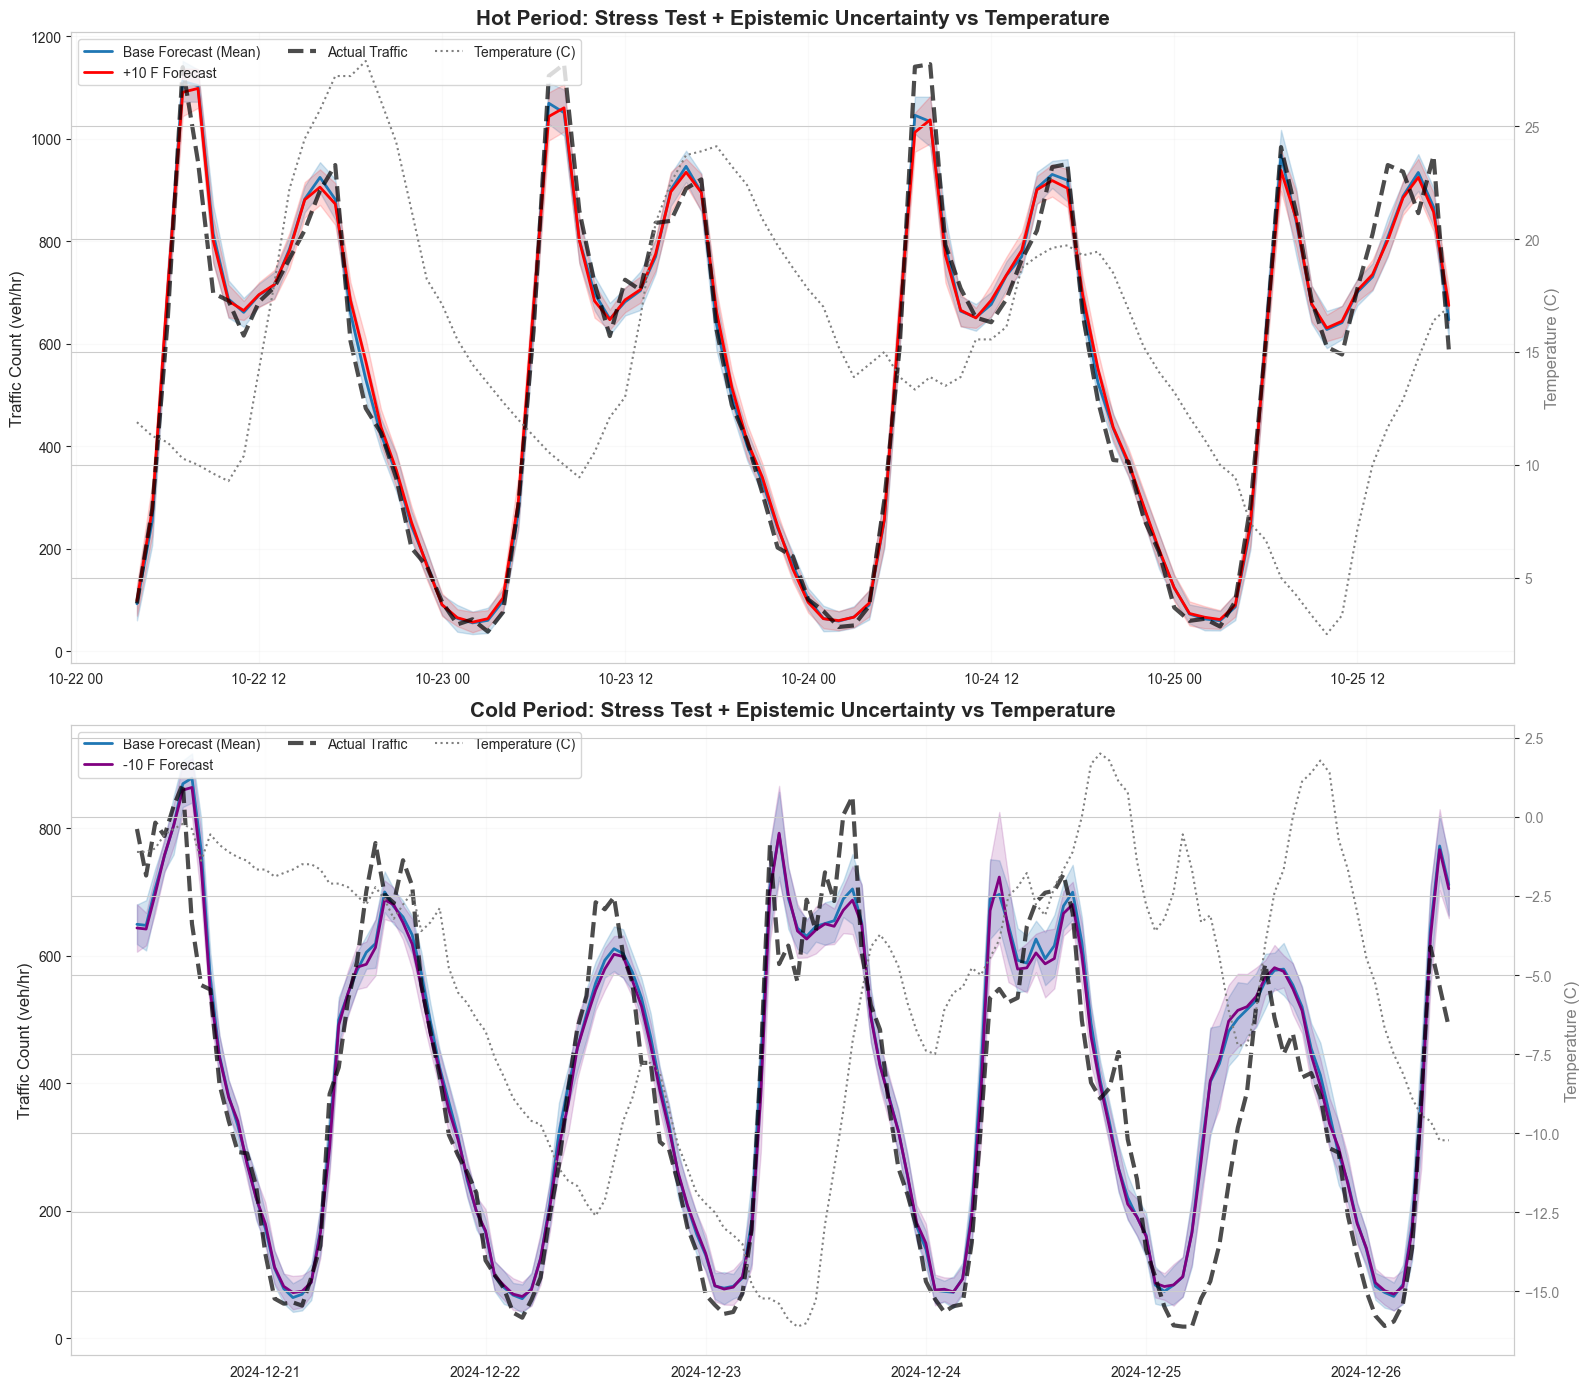

In [55]:
# == Dual-axis: Stress Test + Epistemic Uncertainty + Temperature Overlay ==
# (Matching the exact lecture Pt3 Cell 78 style)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

def plot_with_temp(ax, start, end, title,
                   mu_base, low_base, high_base,
                   mu_mod, low_mod, high_mod,
                   mod_color, mod_label):
    """Lecture-style dual-axis: Traffic + Temperature with MC Dropout CI."""
    # Prepare primary data
    t = test_window_df['timestamp'].iloc[start:end]
    actual = y_test_true_inv[start:end]

    # Get temperature in Fahrenheit for the lecture-style axis
    if 'temp_c' in test_window_df.columns:
        temp_c = test_window_df['temp_c'].iloc[start:end].values
        temp_f = temp_c * 9/5 + 32  # convert C -> F for display
    else:
        temp_f = np.zeros(end - start)

    # --- Secondary Axis for Temperature ---
    ax_temp = ax.twinx()
    ax_temp.plot(t, temp_f, color='gray', lw=1.5, ls=':',
                 label='Outdoor Temp (\u00b0F)')
    ax_temp.set_ylabel('Temperature (\u00b0F)', color='gray', fontsize=12)
    ax_temp.tick_params(axis='y', labelcolor='gray')

    # --- Primary Axis for Traffic ---
    ax.plot(t, mu_base, label='Base Forecast (Mean)', color='C0', lw=2)
    ax.fill_between(t, low_base, high_base, color='C0', alpha=0.2)

    ax.plot(t, mu_mod, label=mod_label, color=mod_color, lw=2)
    ax.fill_between(t, low_mod, high_mod, color=mod_color, alpha=0.15)

    ax.plot(t, actual, color='black', linestyle='--', linewidth=3,
            label='ACTUAL Traffic', alpha=0.7)

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_ylabel('Traffic Count (veh/hr)', fontsize=12)

    # Merging legends from both axes (lecture style)
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_temp.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left', ncol=3)
    ax.grid(True, alpha=0.1)

# Execute Plot 1: Hot Period (Summer)
hot_time = test_window_df['timestamp'].iloc[h_idx] if h_idx < len(test_window_df) else 'N/A'
plot_with_temp(ax1, h_start, h_end,
               f'Summer: Heatwave Stress Test vs. Temp Signal ({hot_time})',
               mu_h_base, lo_h_base, hi_h_base,
               mu_h_hot, lo_h_hot, hi_h_hot,
               'red', '+10\u00b0F Forecast')

# Execute Plot 2: Cold Period (Winter)
cold_time = test_window_df['timestamp'].iloc[c_idx] if c_idx < len(test_window_df) else 'N/A'
plot_with_temp(ax2, c_start, c_end,
               f'Winter: Cold Snap Stress Test vs. Temp Signal ({cold_time})',
               mu_c_base, lo_c_base, hi_c_base,
               mu_c_cold, lo_c_cold, hi_c_cold,
               'purple', '-10\u00b0F Forecast')

plt.tight_layout()
plt.savefig(PROCESSED / 'viz_epistemic_with_temp.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 11 — Spatial Error Map (Folium)

If you trained the GCN+LSTM in Notebook 02, visualize the MAE per station on a map.

In [56]:
# ── Per-station LSTM error map ──
# Run LSTM on each station to get per-station MAE
station_errors = []
for sid in station_map['station_id'].unique():
    sdf = df[df['station_id'] == sid].sort_values('timestamp').dropna(subset=feature_cols + [target_col])
    if len(sdf) < SEQ_LENGTH + 50:
        continue

    sx = scaler_x.transform(sdf[feature_cols])
    sy = scaler_y.transform(sdf[[target_col]])
    sX, sY = create_sequences(sx, sy, SEQ_LENGTH)

    # Take the last 20% as test
    split = int(len(sX) * 0.8)
    sX_test = torch.tensor(sX[split:], dtype=torch.float32)
    sY_test = sy[split + SEQ_LENGTH:].flatten()

    if len(sX_test) == 0:
        continue

    preds_s = get_predictions(lstm_model, sX_test, device)
    preds_inv = scaler_y.inverse_transform(preds_s).flatten()
    true_inv  = scaler_y.inverse_transform(sY_test.reshape(-1, 1)).flatten()

    if len(preds_inv) != len(true_inv):
        min_len = min(len(preds_inv), len(true_inv))
        preds_inv = preds_inv[:min_len]
        true_inv = true_inv[:min_len]

    mae = mean_absolute_error(true_inv, preds_inv)
    coord = station_map[station_map['station_id'] == sid][['latitude', 'longitude']].values
    if len(coord) > 0:
        station_errors.append({
            'station_id': sid, 'mae': mae,
            'latitude': coord[0][0], 'longitude': coord[0][1]
        })

error_df = pd.DataFrame(station_errors)
print(f"Computed per-station MAE for {len(error_df)} stations")
error_df.sort_values('mae', ascending=False).head(10)

KeyboardInterrupt: 

In [ ]:
# == Folium Spatial Error Map ==
m5 = folium.Map(
    location=ct_center, zoom_start=9,
    tiles='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
    attr='&copy; CARTO &copy; OSM'
)

max_mae = error_df['mae'].max()
for _, row in error_df.iterrows():
    norm_err = row['mae'] / max_mae
    r = int(255 * norm_err)
    g = int(255 * (1 - norm_err))
    color = f'#{r:02x}{g:02x}00'

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(5, norm_err * 20),
        color=color, fill=True, fill_color=color, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>Station: {row['station_id']}</b><br>"
            f"LSTM MAE: {row['mae']:.1f} veh/hr",
            max_width=200
        ),
        tooltip=f"{row['station_id']}: MAE={row['mae']:.0f}"
    ).add_to(m5)

m5.save(str(PROCESSED / 'map_spatial_error.html'))
print("Saved: map_spatial_error.html")

from IPython.display import HTML
HTML(m5._repr_html_())


Saved: map_spatial_error.html


---
## Summary of All Saved Outputs

In [ ]:
print("\n" + "="*60)
print("NOTEBOOK 03 COMPLETE")
print("="*60)
print(f"\nAll outputs saved to: {PROCESSED}")
print("\nFolium Maps (open in browser):")
for f in sorted(PROCESSED.glob('map_*.html')):
    print(f"  {f.name}")
print("\nVisualizations:")
for f in sorted(PROCESSED.glob('viz_*.png')):
    print(f"  {f.name}")


NOTEBOOK 03 COMPLETE

All outputs saved to: C:\Users\owner\Downloads\Masters\Masters_Spring_2026\Advanced Deep Learning\Traffic Project 2\processed

Folium Maps (open in browser):
  map_graph_edges.html
  map_hourly_traffic_animation.html
  map_spatial_error.html
  map_station_locations.html
  map_traffic_heatmap.html

Visualizations:
  viz_epistemic_with_temp.png
  viz_global_attention.png
  viz_local_attention.png
  viz_mc_dropout_peak.png
  viz_mc_stress_uncertainty.png
  viz_peak_zoom.png
  viz_shap_feature_importance.png
  viz_shap_pulse.png
  viz_shap_waterfall.png
  viz_stress_test.png
